# QMSS Hackathon 2026 — Project 4 (Health Version)
## Public Rhetoric on Reddit & Sentiment Analysis

**Objective:** Examine public rhetoric on Reddit about water quality — comparing **contamination & health-risk framing** (PFAS, lead, toxicity, crisis) vs **access & solution framing** (charities, filters, safe water projects, community access).

### Outputs
1. Word cloud of Reddit posts about water quality topics
2. Bar chart of most frequent words or phrases
3. Sentiment comparison: contamination/harm vs access/solutions
4. Sentiment trend over time
5. Statistical test for sentiment difference between topics

In [99]:
!pip install praw vaderSentiment wordcloud matplotlib seaborn pandas

In [100]:
import praw
import pandas as pd
import numpy as np
import re
from datetime import datetime
from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

---
## 1. Reddit Data Collection (PRAW)

We search across all of Reddit for two contrasting framings (same broad theme, different tone):
- **Topic A (Contamination & health risk):** fear/harm/crisis language — PFAS, lead, toxicity, health risk from polluted water
- **Topic B (Access & solutions):** hope/NGO/practical fixes — charities, filters, safe-water projects, community access

In [101]:
reddit = praw.Reddit(
    client_id='qPdDcEKwEecqp5V2KQi_yg',
    client_secret='sbZdHIXAm4DeVIfLN-pl6d_tBTUPVA',
    user_agent='QMSS301-Scraper by u/Intrepid-Adagio-6312'
)

In [102]:
SUBREDDITS = "all"

TOPIC_A_TERMS = [
    "PFAS in drinking water",
    "lead poisoning water",
    "water contamination health risk",
    "toxic chemicals in water",
]
TOPIC_B_TERMS = [
    "clean water charity",
    "water filter recommendations",
    "bringing clean water",
    "safe water for communities",
]

LIMIT_PER_TERM = 100  # posts per search term


def scrape_posts(search_terms, topic_label):
    """Search Reddit for each term and return a DataFrame."""
    rows = []
    for term in search_terms:
        print(f"  Searching: '{term}' ...")
        results = reddit.subreddit(SUBREDDITS).search(term, sort="relevance", limit=LIMIT_PER_TERM)
        for post in results:
            rows.append({
                "topic": topic_label,
                "search_term": term,
                "title": post.title,
                "body": post.selftext,
                "score": post.score,
                "num_comments": post.num_comments,
                "created_utc": post.created_utc,
                "subreddit": str(post.subreddit),
                "url": "https://www.reddit.com" + post.permalink,
                "post_id": post.id,
            })
    df = pd.DataFrame(rows)
    print(f"  → {len(df)} posts collected for '{topic_label}'")
    return df

In [103]:
print("Collecting Topic A (contamination & health risk) ...")
df_a = scrape_posts(TOPIC_A_TERMS, "water_pollution")

print("\nCollecting Topic B (access & solutions) ...")
df_b = scrape_posts(TOPIC_B_TERMS, "water_access")

df = pd.concat([df_a, df_b], ignore_index=True)
df.drop_duplicates(subset="post_id", keep="first", inplace=True)

df["date"] = pd.to_datetime(df["created_utc"], unit="s")
df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")

print(f"\nTotal unique posts: {len(df)}")
print(df["topic"].value_counts())
df.head()

  Searching: 'PFAS in drinking water' ...
  Searching: 'lead poisoning water' ...
  Searching: 'water contamination health risk' ...
  Searching: 'toxic chemicals in water' ...
  → 400 posts collected for 'water_pollution'

  Searching: 'clean water charity' ...
  Searching: 'water filter recommendations' ...
  Searching: 'bringing clean water' ...
  Searching: 'safe water for communities' ...
  → 400 posts collected for 'water_access'

Total unique posts: 776
topic
water_access       391
water_pollution    385
Name: count, dtype: int64


,topic,search_term,title,body,score,num_comments,created_utc,subreddit,url,post_id,date,date_str
0,water_pollution,PFAS in drinking water,Scientists solved longstanding mystery of orig...,,17935,527,1.763943e+09,science,https://www.reddit.com/r/science/comments/1p52...,1p52d6k,2025-11-24 00:12:54,2025-11-24
1,water_pollution,PFAS in drinking water,"White House Admin Plans to Delay, Eliminate Li...",,7948,342,1.747312e+09,Futurology,https://www.reddit.com/r/Futurology/comments/1...,1kn6rz4,2025-05-15 12:20:00,2025-05-15
2,water_pollution,PFAS in drinking water,EPA withdraws plan to regulate industrial pois...,https://www.azfamily.com/2025/01/23/epa-withdr...,5020,661,1.737819e+09,economicCollapse,https://www.reddit.com/r/economicCollapse/comm...,1i9pivg,2025-01-25 15:38:09,2025-01-25
3,water_pollution,PFAS in drinking water,Scientists published new method to chemically ...,,31220,686,1.671388e+09,science,https://www.reddit.com/r/science/comments/zp4y...,zp4y2q,2022-12-18 18:33:34,2022-12-18
4,water_pollution,PFAS in drinking water,A new study found PFAS “forever chemicals” in ...,,5214,192,1.747915e+09,science,https://www.reddit.com/r/science/comments/1kso...,1ksoy05,2025-05-22 12:03:17,2025-05-22


In [104]:
df.to_csv("health_reddit_raw.csv", index=False)
print("Saved → health_reddit_raw.csv")
print(f"Shape: {df.shape}")

Saved → health_reddit_raw.csv
Shape: (776, 12)


---
## 2. Text Preprocessing & Sentiment Analysis

- Combine title + body into one text field
- Clean: lowercase, remove URLs, special characters
- Apply **VADER** sentiment (designed for social media text)
- Each post gets a compound score: **-1** (very negative) to **+1** (very positive)

In [105]:
def clean_text(text):
    """Lowercase, strip URLs, non-alpha chars, and extra whitespace."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = (df["title"].fillna("") + " " + df["body"].fillna("")).apply(clean_text)

STOPWORDS = set(
    "i me my myself we our ours ourselves you your yours yourself yourselves "
    "he him his himself she her hers herself it its itself they them their "
    "theirs themselves what which who whom this that these those am is are was "
    "were be been being have has had having do does did doing a an the and but "
    "if or because as until while of at by for with about against between "
    "through during before after above below to from up down in out on off "
    "over under again further then once here there when where why how all each "
    "every both few more most other some such no nor not only own same so than "
    "too very s t can will just don should now d ll m o re ve y ain aren couldn "
    "didn doesn hadn hasn haven isn ma mightn mustn needn shan shouldn wasn "
    "weren won wouldn would could also would like get one even really people "
    "think know much many still going go got way make things thing say said "
    "something use using used new let "
    "into onto upon within without against toward towards "
    "want wants wanted needing need needs "
    "any anybody anymore anyone anything anyway anywhere "
    "maybe perhaps probably definitely actually basically literally "
    "well yes yeah yea nah nope okay ok sure "
    "someone everyone somebody anybody nobody "
    "everything nothing "
    "thank thanks please sorry "
    "kinda sorta gonna gotta wanna "
    "seems seemed seem feeling feels felt "
    "looks looking looked "
    "thought thinking think thinks "
    "ask asking asked tell telling told say says saying "
    "come coming came take taking took give giving gave "
    "see seeing saw try trying tried help helping helped "
    "find finding found keep keeping kept put puts mean means "
    "lot lots bit little big long short day days time times year years "
    "tho tbh imo fwiw edit update deleted removed "
    "subreddit reddit".split()
)

df["clean_tokens"] = df["text"].apply(
    lambda t: [w for w in t.split() if w not in STOPWORDS and len(w) > 2]
)

print("Sample cleaned text:")
print(df["clean_tokens"].iloc[0][:15])

Sample cleaned text:
['scientists', 'solved', 'longstanding', 'mystery', 'origin', 'pfas', 'forever', 'chemicals', 'contaminating', 'water', 'north', 'carolina', 'local', 'textile', 'manufacturing']


In [106]:
analyzer = SentimentIntensityAnalyzer()

scores = df["text"].apply(lambda t: analyzer.polarity_scores(t))
df["sentiment_neg"] = scores.apply(lambda s: s["neg"])
df["sentiment_neu"] = scores.apply(lambda s: s["neu"])
df["sentiment_pos"] = scores.apply(lambda s: s["pos"])
df["sentiment_compound"] = scores.apply(lambda s: s["compound"])

df["sentiment_label"] = df["sentiment_compound"].apply(
    lambda c: "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")
)

print("Sentiment distribution:")
print(df["sentiment_label"].value_counts())
print(f"\nMean compound by topic:")
print(df.groupby("topic")["sentiment_compound"].mean())

Sentiment distribution:
sentiment_label
positive    460
negative    253
neutral      63
Name: count, dtype: int64

Mean compound by topic:
topic
water_access       0.636659
water_pollution   -0.111869
Name: sentiment_compound, dtype: float64


---
## 3. Output 1 — Word Cloud

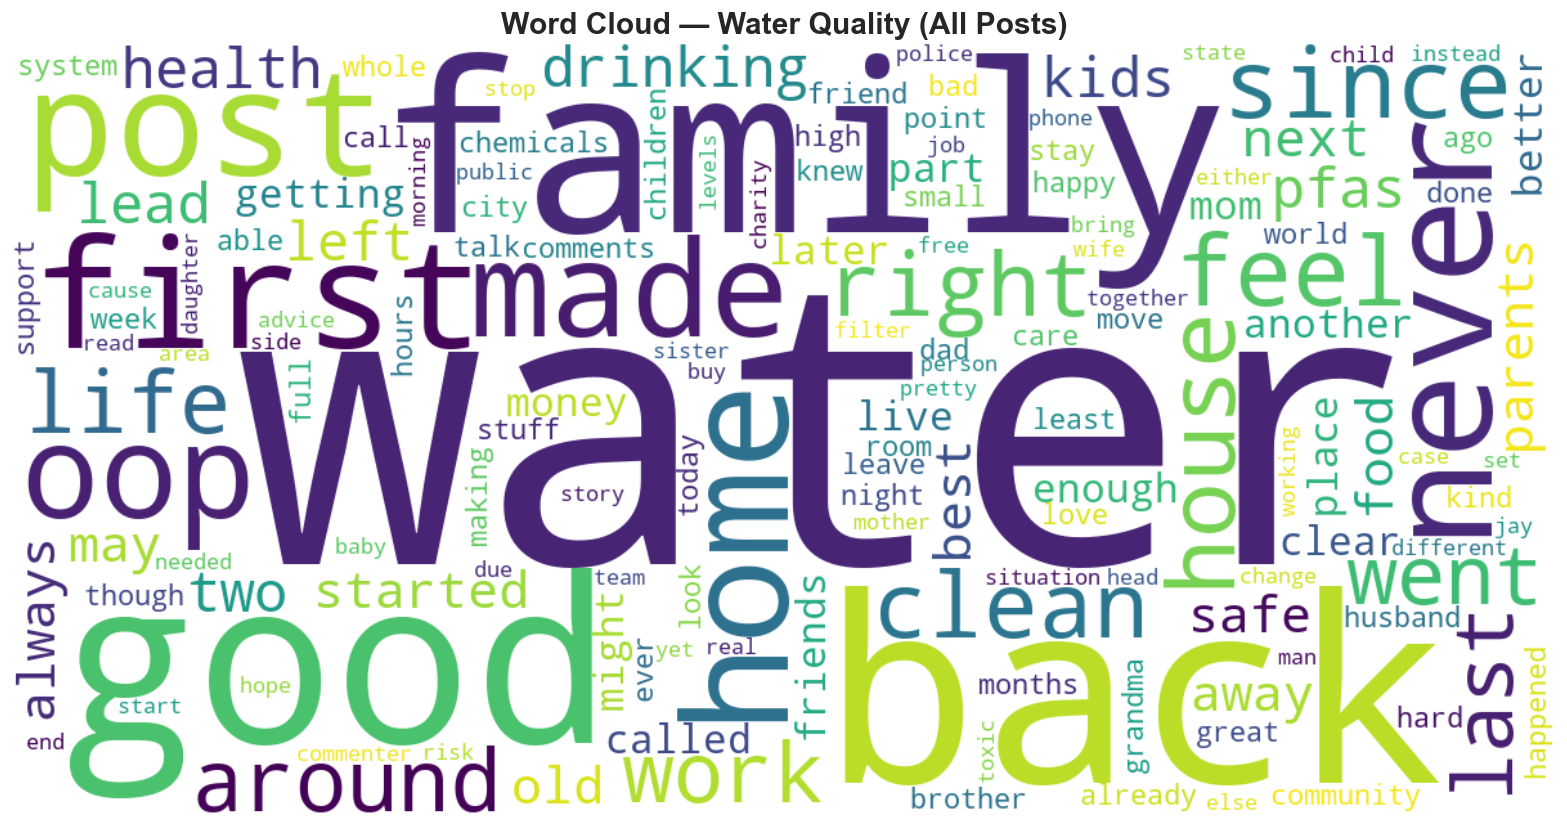

Saved → output1_wordcloud.png


In [107]:
all_tokens = df["clean_tokens"].explode()
word_freq = Counter(all_tokens).most_common(200)

wc = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="viridis",
    max_words=150,
).generate_from_frequencies(dict(word_freq))

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.set_title("Word Cloud — Water Quality (All Posts)", fontsize=18, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("output1_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output1_wordcloud.png")

---
## 4. Output 2 — Bar Chart of Most Frequent Words

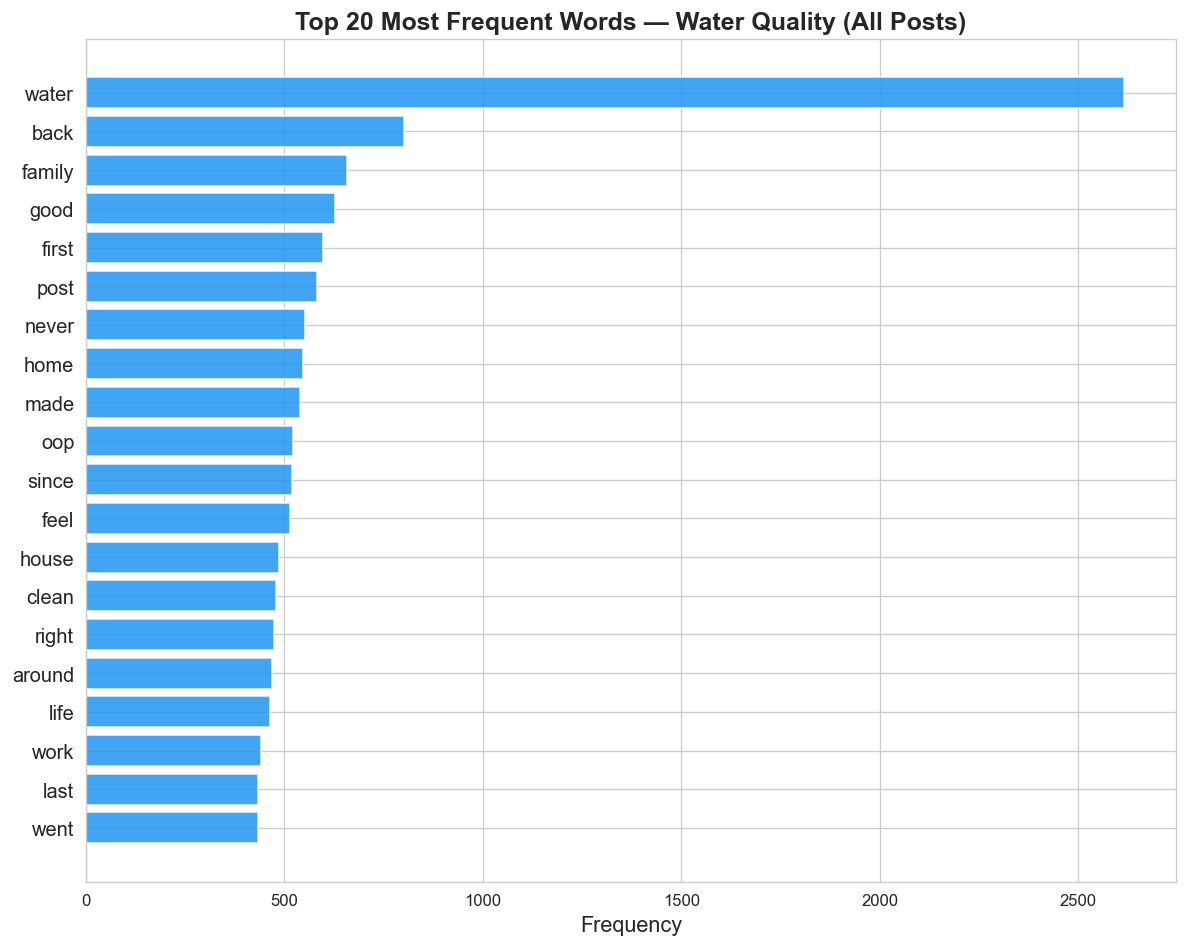

Saved → output2_word_frequency.png


In [108]:
TOP_N = 20

all_tokens = df["clean_tokens"].explode()
top_words = Counter(all_tokens).most_common(TOP_N)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(words)), counts, color="#2196F3", alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("Frequency", fontsize=13)
ax.set_title(f"Top {TOP_N} Most Frequent Words — Water Quality (All Posts)", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig("output2_word_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output2_word_frequency.png")

---
## 5. Output 3 — Sentiment Comparison: Contamination vs Access/Solutions

/var/folders/qs/72_944g15gz749x17vmfg0f40000gn/T/ipykernel_19613/3713352556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="topic", y="sentiment_compound", palette=palette, ax=axes[1])


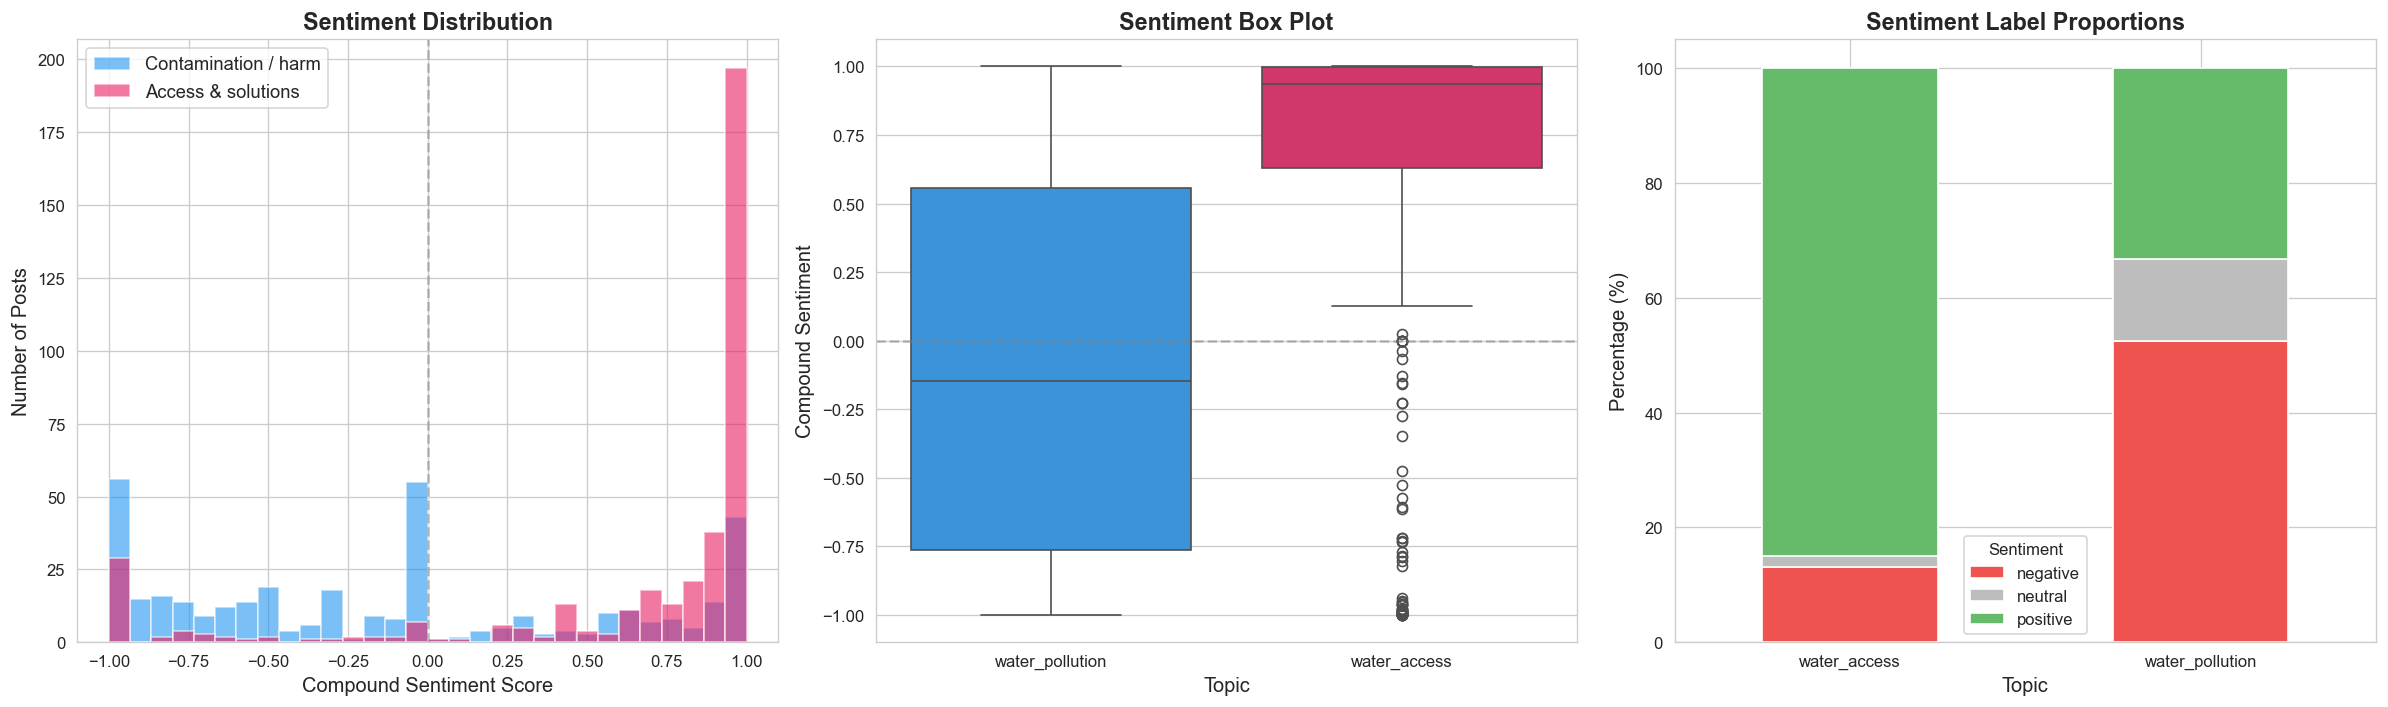

Saved → output3_sentiment_comparison.png


In [109]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Distribution of compound sentiment scores
for topic, label, color in [("water_pollution", "Contamination / harm", "#2196F3"), ("water_access", "Access & solutions", "#E91E63")]:
    subset = df.loc[df["topic"] == topic, "sentiment_compound"]
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
axes[0].set_xlabel("Compound Sentiment Score", fontsize=12)
axes[0].set_ylabel("Number of Posts", fontsize=12)
axes[0].set_title("Sentiment Distribution", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].axvline(0, color="gray", linestyle="--", alpha=0.5)

# (b) Box plot comparison
palette = {"water_pollution": "#2196F3", "water_access": "#E91E63"}
sns.boxplot(data=df, x="topic", y="sentiment_compound", palette=palette, ax=axes[1])
axes[1].set_xlabel("Topic", fontsize=12)
axes[1].set_ylabel("Compound Sentiment", fontsize=12)
axes[1].set_title("Sentiment Box Plot", fontsize=14, fontweight="bold")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)

# (c) Sentiment label proportions
ct = pd.crosstab(df["topic"], df["sentiment_label"], normalize="index") * 100
ct = ct[["negative", "neutral", "positive"]]
ct.plot(kind="bar", stacked=True, ax=axes[2],
        color=["#ef5350", "#bdbdbd", "#66bb6a"], edgecolor="white")
axes[2].set_xlabel("Topic", fontsize=12)
axes[2].set_ylabel("Percentage (%)", fontsize=12)
axes[2].set_title("Sentiment Label Proportions", fontsize=14, fontweight="bold")
axes[2].legend(title="Sentiment", fontsize=10)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("output3_sentiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output3_sentiment_comparison.png")

---
## 6. Output 4 — Sentiment Trend Over Time

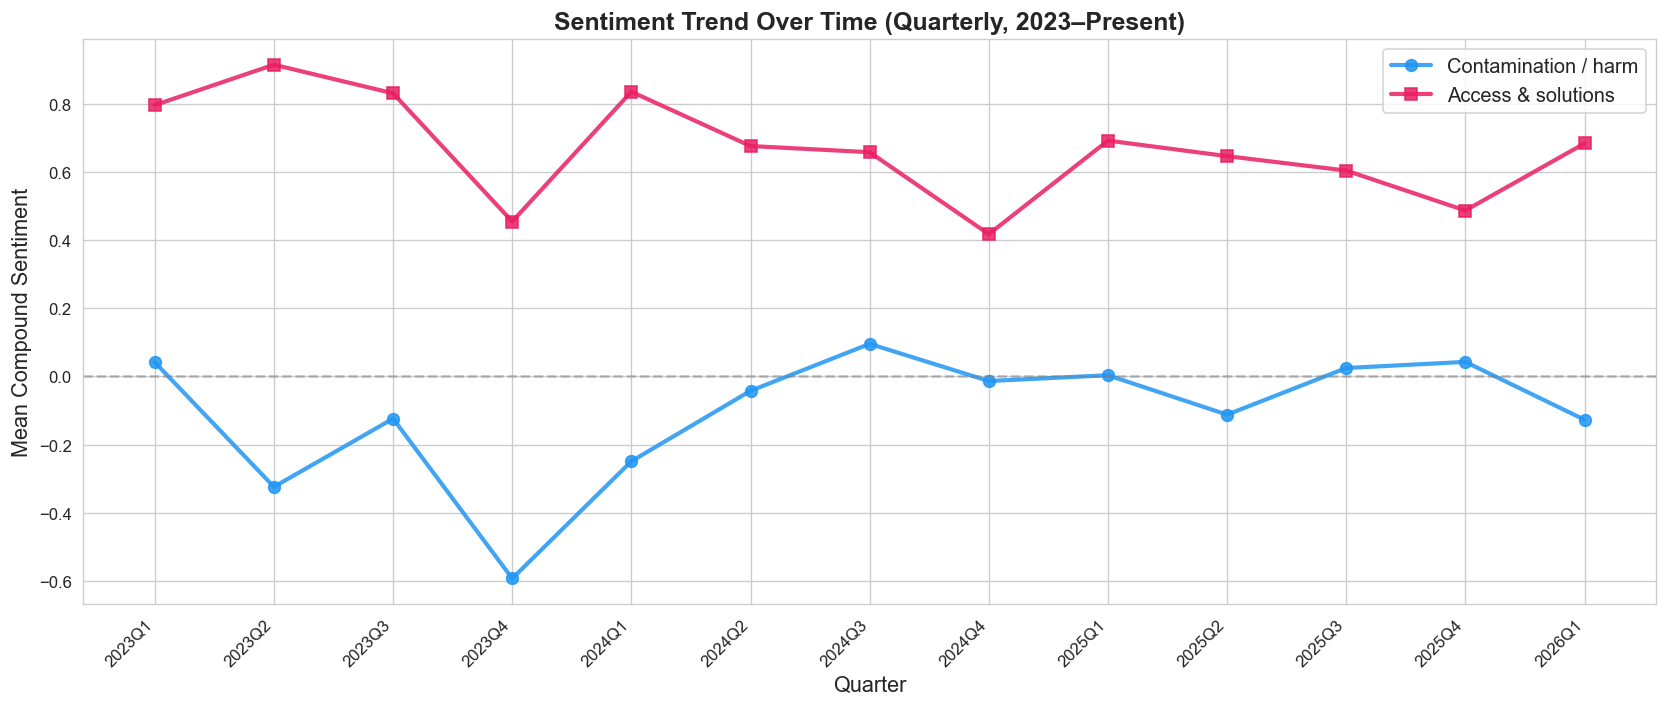

Saved → output4_sentiment_trend.png

Posts included (2023+): 593 / 776 total


In [110]:
recent = df[df["date"] >= "2023-01-01"].copy()
recent["quarter"] = recent["date"].dt.to_period("Q").astype(str)

quarterly = (
    recent.groupby(["quarter", "topic"])
    .agg(mean_sentiment=("sentiment_compound", "mean"),
         post_count=("sentiment_compound", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for topic, label, color, marker in [
    ("water_pollution", "Contamination / harm", "#2196F3", "o"),
    ("water_access", "Access & solutions", "#E91E63", "s"),
]:
    subset = quarterly[quarterly["topic"] == topic].sort_values("quarter")
    ax.plot(subset["quarter"], subset["mean_sentiment"],
            marker=marker, label=label, color=color, linewidth=2.5,
            markersize=7, alpha=0.85)

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Quarter", fontsize=13)
ax.set_ylabel("Mean Compound Sentiment", fontsize=13)
ax.set_title("Sentiment Trend Over Time (Quarterly, 2023–Present)", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("output4_sentiment_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output4_sentiment_trend.png")
print(f"\nPosts included (2023+): {len(recent)} / {len(df)} total")

---
## 7. Output 5 — Statistical Test

**H₀:** There is no significant difference in sentiment between contamination/harm-framed posts and access/solutions-framed posts.  
**H₁:** Sentiment differs significantly between the two topic groups.

We use both:
- **Independent-samples t-test** (parametric)
- **Mann-Whitney U test** (non-parametric, more robust for skewed data)

In [111]:
group_a = df.loc[df["topic"] == "water_pollution", "sentiment_compound"]
group_b = df.loc[df["topic"] == "water_access", "sentiment_compound"]

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
desc = df.groupby("topic")["sentiment_compound"].describe()
print(desc.to_string())

print("\n" + "=" * 60)
print("INDEPENDENT SAMPLES T-TEST")
print("=" * 60)
t_stat, t_pval = stats.ttest_ind(group_a, group_b, equal_var=False)
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {t_pval:.6f}")
print(f"  Significant at α=0.05? {'YES ✓' if t_pval < 0.05 else 'NO ✗'}")

print("\n" + "=" * 60)
print("MANN-WHITNEY U TEST (non-parametric)")
print("=" * 60)
u_stat, u_pval = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
print(f"  U-statistic : {u_stat:.4f}")
print(f"  p-value     : {u_pval:.6f}")
print(f"  Significant at α=0.05? {'YES ✓' if u_pval < 0.05 else 'NO ✗'}")

cohens_d = (group_a.mean() - group_b.mean()) / np.sqrt((group_a.std()**2 + group_b.std()**2) / 2)
print(f"\n  Cohen's d (effect size): {cohens_d:.4f}")
print(f"  Interpretation: {'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'}")

DESCRIPTIVE STATISTICS
                 count      mean       std     min     25%     50%      75%     max
topic                                                                              
water_access     391.0  0.636659  0.600195 -0.9998  0.6295  0.9356  0.99615  1.0000
water_pollution  385.0 -0.111869  0.680129 -0.9998 -0.7623 -0.1469  0.55740  0.9999

INDEPENDENT SAMPLES T-TEST
  t-statistic : -16.2462
  p-value     : 0.000000
  Significant at α=0.05? YES ✓

MANN-WHITNEY U TEST (non-parametric)
  U-statistic : 30668.5000
  p-value     : 0.000000
  Significant at α=0.05? YES ✓

  Cohen's d (effect size): -1.1670
  Interpretation: large


---
## 8. Save Final Dataset

In [112]:
export_cols = [
    "topic", "search_term", "title", "body", "text",
    "score", "num_comments", "subreddit", "url", "post_id",
    "date", "date_str",
    "sentiment_compound", "sentiment_pos", "sentiment_neg", "sentiment_neu",
    "sentiment_label",
]
df[export_cols].to_csv("health_reddit_sentiment.csv", index=False)
print("Saved → health_reddit_sentiment.csv")
print(f"Final shape: {df.shape}")
print(f"\nContamination/harm posts:   {len(df[df['topic']=='water_pollution'])}")
print(f"Access/solutions posts:     {len(df[df['topic']=='water_access'])}")

print("\n--- ALL OUTPUTS ---")
print("  health_reddit_raw.csv          (raw scraped data)")
print("  health_reddit_sentiment.csv    (with sentiment scores)")
print("  output1_wordcloud.png")
print("  output2_word_frequency.png")
print("  output3_sentiment_comparison.png")
print("  output4_sentiment_trend.png")

Saved → health_reddit_sentiment.csv
Final shape: (776, 19)

Contamination/harm posts:   385
Access/solutions posts:     391

--- ALL OUTPUTS ---
  health_reddit_raw.csv          (raw scraped data)
  health_reddit_sentiment.csv    (with sentiment scores)
  output1_wordcloud.png
  output2_word_frequency.png
  output3_sentiment_comparison.png
  output4_sentiment_trend.png
